# 01 - EDA

Este notebook explora `habitia_madrid_2018`, fija la variable objetivo y deja
identificados los problemas que los notebooks 02 y 03 tienen que resolver. Todo el
código de apoyo vive en `src/eda_utils.py`, de modo que aquí se ve la evidencia y no
la fontanería.

## 0. Procedencia del dataset

El recorrido de esta cadena empieza en `data/interim/habitia_madrid_2018.csv`. Ese fichero lo
construye [`00_construccion_dataset.ipynb`](00_construccion_dataset.ipynb), donde se pueden explorar los detalles de la constr

In [25]:
import os, sys, warnings
from pathlib import Path

RAIZ = Path.cwd()
while not (RAIZ / "src").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
os.chdir(RAIZ); sys.path.insert(0, str(RAIZ))

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import rutas
from src.eda_utils import (missing_report,
    correlaciones_numericas, plot_corr_matrix, vif_table,
    detectar_redundancia_categorica, graficoVcramer, Vcramer,
    summarize_outliers
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

df = pd.read_csv(rutas.RUTA_DATASET_BASE, sep=";").set_index("ASSETID")
print(f"{df.shape[0]:,} filas x {df.shape[1]} columnas")

75,469 filas x 42 columnas


## 1. Taxonomía de variables

Antes de mirar nada hay que decidir **cómo se trata cada columna**, porque un `0/1` y
un contador no admiten el mismo descriptivo ni el mismo gráfico. Esta clasificación se
arrastra durante todo el notebook.

In [26]:
TARGET = "PRICE"

CONTINUAS = [
    "CONSTRUCTEDAREA", "DISTANCE_TO_CITY_CENTER", "DISTANCE_TO_METRO",
    "DISTANCE_TO_CASTELLANA", "alq_mediana_eur_m2_barrio", "dist_centro_educativo_m",
    "dist_parque_m", "dist_espacio_deporte_m", "dist_centro_medico_m",
    "delitos_per_10k_barrio", "indice_vulnerabilidad",
]
DISCRETAS = [
    "ROOMNUMBER", "BATHNUMBER", "FLOORCLEAN", "CADCONSTRUCTIONYEAR",
    "CADMAXBUILDINGFLOOR", "CADDWELLINGCOUNT", "CONSTRUCTIONYEAR",
]
ORDINAL = ["CADASTRALQUALITYID"]
FLAGS_BINARIOS = [c for c in df.columns if df[c].dropna().isin([0, 1]).all()
                  and c not in CONTINUAS + DISCRETAS + ORDINAL]
CONDICIONAL = ["PARKINGSPACEPRICE", "ISPARKINGSPACEINCLUDEDINPRICE"]

resumen_taxonomia = pd.Series({
    "continuas": len(CONTINUAS), "discretas": len(DISCRETAS),
    "ordinales": len(ORDINAL), "flags binarios": len(FLAGS_BINARIOS),
    "condicionales": len(CONDICIONAL),
})
print(resumen_taxonomia)
print(f"\nFlags binarios: {FLAGS_BINARIOS}")

continuas         11
discretas          7
ordinales          1
flags binarios    20
condicionales      2
dtype: int64

Flags binarios: ['HASTERRACE', 'HASLIFT', 'HASAIRCONDITIONING', 'HASPARKINGSPACE', 'ISPARKINGSPACEINCLUDEDINPRICE', 'HASNORTHORIENTATION', 'HASSOUTHORIENTATION', 'HASEASTORIENTATION', 'HASWESTORIENTATION', 'HASBOXROOM', 'HASWARDROBE', 'HASSWIMMINGPOOL', 'HASDOORMAN', 'HASGARDEN', 'ISDUPLEX', 'ISSTUDIO', 'ISINTOPFLOOR', 'BUILTTYPEID_1', 'BUILTTYPEID_2', 'BUILTTYPEID_3']


## 2. La variable objetivo: `PRICE`

Dos cuestiones que resolver antes de modelar: la forma de la distribución y si hay
alguna variable que la contamine.

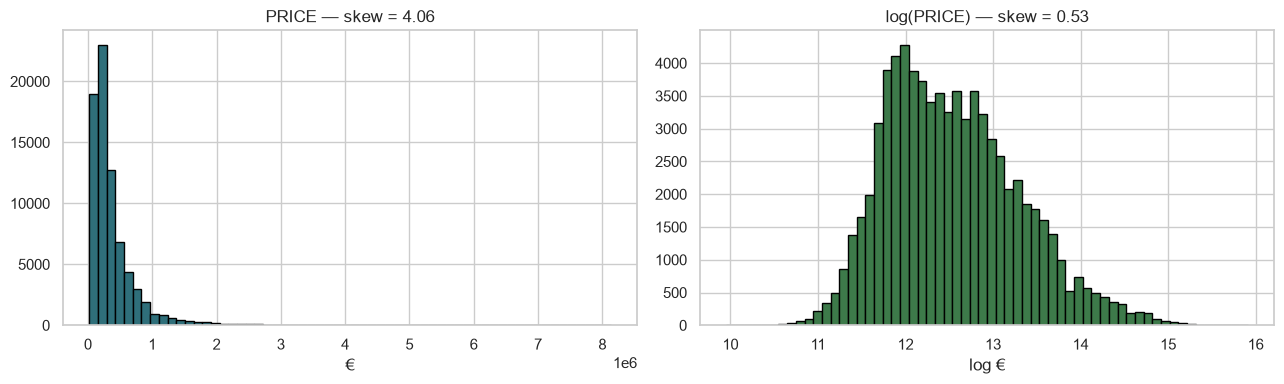

count       75,469
mean       387,362
std        410,391
min         21,000
25%        156,000
50%        256,000
75%        455,000
max      8,133,000
Name: PRICE, dtype: str


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df[TARGET], bins=60, edgecolor="black", color="#2f6f7a")
axes[0].set_title(f"PRICE — skew = {df[TARGET].skew():.2f}")
axes[0].set_xlabel("€")
axes[1].hist(np.log(df[TARGET]), bins=60, edgecolor="black", color="#3d7a4a")
axes[1].set_title(f"log(PRICE) — skew = {np.log(df[TARGET]).skew():.2f}")
axes[1].set_xlabel("log €")
plt.tight_layout(); plt.show()

print(df[TARGET].describe().apply(lambda v: f"{v:,.0f}"))

`PRICE` tiene una cola derecha muy larga (skew ≈ 8). En `log` la distribución es
prácticamente simétrica.

**Decisión: se modela `log(PRICE)`.** Dos consecuencias:

1. Los coeficientes se leen como **efectos multiplicativos** (elasticidades, si la
   variable también entra en log).
2. Al devolver la predicción a euros, `exp(ŷ)` **está sesgado a la baja** (desigualdad
   de Jensen). Se corrige más tarde *smearing* de Duan (ver notebooks 07 y 08).

### 2.1 `UNITPRICE` es redundante

`UNITPRICE` es el precio por m². Si es exactamente `PRICE / CONSTRUCTEDAREA`, contiene
el objetivo y no puede entrar en el modelo bajo ningún concepto.

In [28]:
ratio = df["UNITPRICE"] / (df[TARGET] / df["CONSTRUCTEDAREA"])
print(f"UNITPRICE / (PRICE/CONSTRUCTEDAREA):")
print(f"  mediana = {ratio.median():.6f}")
print(f"  % de filas con ratio en [0,99 , 1,01] = {ratio.between(0.99, 1.01).mean():.2%}")
print("\n-> identidad algebraica: es el target dividido por una feature. ELIMINAR.")

UNITPRICE / (PRICE/CONSTRUCTEDAREA):
  mediana = 1.000000
  % de filas con ratio en [0,99 , 1,01] = 100.00%

-> identidad algebraica: es el target dividido por una feature. ELIMINAR.


## 3. Valores faltantes

Tres problemas distintos, cada uno con su tratamiento.

In [29]:
falta = missing_report(df)
falta[falta["missing_n"] > 0]

,missing_n,missing_pct,dtype
CONSTRUCTIONYEAR,45183,59.869615,float64
FLOORCLEAN,2975,3.942016,float64
CADASTRALQUALITYID,1,0.001325,float64


### 3.1 `CONSTRUCTIONYEAR`, en comparación con `CADCONSTRUCTIONYEAR`

Dos variables miden lo mismo. Una la declara el anunciante y está mayoritariamente
vacía; la otra viene del catastro y está completa.

In [30]:
comparacion = pd.DataFrame({
    "% nulos": [df["CONSTRUCTIONYEAR"].isna().mean() * 100,
                df["CADCONSTRUCTIONYEAR"].isna().mean() * 100],
    "fuente": ["declarado por el anunciante", "cruce catastral"],
}, index=["CONSTRUCTIONYEAR", "CADCONSTRUCTIONYEAR"])
print(comparacion.round(1))
print("\n-> eliminar CONSTRUCTIONYEAR, conservar la catastral.")

                     % nulos                       fuente
CONSTRUCTIONYEAR        59.9  declarado por el anunciante
CADCONSTRUCTIONYEAR      0.0              cruce catastral

-> eliminar CONSTRUCTIONYEAR, conservar la catastral.


### 3.2 `FLOORCLEAN` y `CADASTRALQUALITYID`: imputar

Nulos minoritarios en dos variables que sí interesan.

- `FLOORCLEAN` → **mediana condicional** a tipo de inmueble (`BUILTTYPEID_*`) y tramo
  de altura del edificio. Una mediana global asignaría un 2º piso a un chalet.
- `CADASTRALQUALITYID` → **moda**.

> Aquí se calculan sobre el dataset completo porque este notebook es exploratorio. En
> el notebook 04 se ajustan **solo sobre train** (`src/imputacion.py`), que es lo que
> evita la fuga de información en el pipeline real.

In [ ]:
print(f"FLOORCLEAN nulos:          {df['FLOORCLEAN'].isna().sum():,} ({df['FLOORCLEAN'].isna().mean():.2%})")
print(f"CADASTRALQUALITYID nulos:  {df['CADASTRALQUALITYID'].isna().sum():,} ({df['CADASTRALQUALITYID'].isna().mean():.2%})")


print(f"\nCADMAXBUILDINGFLOOR == 0 (sin match catastral): {(df['CADMAXBUILDINGFLOOR'] == 0).sum():,} filas")
print(f"  precio medio de ese grupo:  {df.loc[df['CADMAXBUILDINGFLOOR'] == 0, TARGET].mean():,.0f} €")
print(f"  precio medio del resto:     {df.loc[df['CADMAXBUILDINGFLOOR'] != 0, TARGET].mean():,.0f} €")
print("\n-> el 0 no es 'edificio de altura cero': es 'sin dato', y su precio medio es el MAS ALTO.")
print("   Tratarlo como altura real invertiría la relación. Necesita flag (se resuelve en notebook 02).")

FLOORCLEAN nulos:          2,975 (3.94%)
CADASTRALQUALITYID nulos:  1 (0.00%)

CADMAXBUILDINGFLOOR == 0 (sin match catastral): 79 filas
  precio medio de ese grupo:  922,089 €
  precio medio del resto:     386,801 €

-> el 0 no es 'edificio de altura cero': es 'sin dato', y su precio medio es el MAS ALTO.
   Tratarlo como altura real invertiría la relación. Necesita flag (se resuelve en notebook 02).


### 4. Plazas de parking

Cuando un anuncio incluye la plaza de garaje (`ISPARKINGSPACEINCLUDEDINPRICE`) **dentro del precio**, esperaríamos que `PRICE` está inflado
por un concepto que no es la vivienda, y lo lógico sería restarlo. No obstante, al mirar los valores aparece un problema que conviene documentar.

En todos los casos que hay parking, este está incluido en el precio.

In [32]:
pd.crosstab(df["ISPARKINGSPACEINCLUDEDINPRICE"], df["HASPARKINGSPACE"], normalize="index")

HASPARKINGSPACE,0,1
ISPARKINGSPACEINCLUDEDINPRICE,,
0,1.0,0.0
1,0.0,1.0


Podemos a partir de aquí ver que el precio de parking no es fiable, y es un su mayoría una señal binaria. Por tanto, en vez de sustraer el precio del de la vivienda, dejaremos simplemente la flag de que la casa incluye parking, de tal manera que el modelo al menos capte ese factor, aunque no podamos tener en cuenta el precio del parking.

In [33]:
incluye = (df["ISPARKINGSPACEINCLUDEDINPRICE"] == 1)
pp = df.loc[incluye, "PARKINGSPACEPRICE"]

print(f"Anuncios con plaza incluida en el precio: {incluye.sum():,} ({incluye.mean():.1%})")
print(f"\nValores de PARKINGSPACEPRICE en esas filas:")
print(pp.value_counts().head(8).to_string())
print(f"\n  = 1  ->  {(pp == 1).sum():,} filas ({(pp == 1).mean():.2%})")
print(f"  > 1  ->  {(pp > 1).sum():,} filas")

Anuncios con plaza incluida en el precio: 16,185 (21.4%)

Valores de PARKINGSPACEPRICE en esas filas:
PARKINGSPACEPRICE
1         16179
15001         1
50001         1
220001        1
25001         1
30001         1
131           1

  = 1  ->  16,179 filas (99.96%)
  > 1  ->  6 filas


**`PARKINGSPACEPRICE` vale exactamente `1` en 16.433 de las 16.439 filas.** No es un
precio: es una **señal** que significa "lleva plaza, importe no desglosado". Solo 6
anuncios declaran un importe real.

Consecuencia sobre el ajuste que aplica `src/limpieza.py`: resta **1 €** a 16.433
anuncios (irrelevante frente a un precio medio de ~555.000 €) y un importe real a 6.
Es decir, **el ajuste es prácticamente inocuo, no un saneamiento del target**. Se
mantiene porque en esos 6 casos sí corrige, y porque no hace daño.

Lo que sí importa es la segunda mitad de la decisión: **eliminar las dos columnas de
parking**. `ISPARKINGSPACEINCLUDEDINPRICE` describe *cómo está compuesto el precio*, así
que es información sobre el target, no sobre la vivienda — *leakage* parcial. Y
`PARKINGSPACEPRICE`, siendo una variable constante, no aporta nada. `HASPARKINGSPACE`
(que sí describe el inmueble) se conserva.

## 5. Aplicar la limpieza

Los cuatro pasos anteriores son deterministas (no estiman nada sobre los datos), así que
son seguros de aplicar antes de cualquier partición.

In [34]:
from src.imputacion import fit_imputacion, aplicar_imputacion

df_limpio = df.copy()

df_limpio = df_limpio.drop(columns=["UNITPRICE"])

df_limpio = df_limpio.drop(columns=["PARKINGSPACEPRICE", "ISPARKINGSPACEINCLUDEDINPRICE"])

df_limpio = df_limpio.drop(columns=["CONSTRUCTIONYEAR"])
df_limpio = df_limpio.drop(columns=["BUILTTYPEID_3"])


In [35]:
# Imputamos null en piso por mediana basada en tipo de edificio y número de plantas
# Imputamos null en CADASTRALQUALITYID con su moda (solo hay un caso)

params_imp = fit_imputacion(df_limpio)
df_limpio = aplicar_imputacion(df_limpio, params_imp)

y = np.log(df_limpio[TARGET])
df_limpio["log_PRICE"] = y

DISCRETAS_L = [c for c in DISCRETAS if c in df_limpio.columns]
NUM_EXPLICATIVAS = CONTINUAS + DISCRETAS_L

print(f"{df_limpio.shape[0]:,} filas x {df_limpio.shape[1]} columnas | nulos restantes: {df_limpio.isna().sum().sum()}")

75,469 filas x 38 columnas | nulos restantes: 0


## 6. Outliers

Con `log(PRICE)` como objetivo, la cola de precios deja de ser un problema de escala. El
resto de colas son **viviendas reales** (áticos grandes, chalets), no errores de
medida.

**Decisión: no se winsoriza ni se recorta nada.** Donde la cola sí puede ser un problema, se trata con
la forma funcional (log o binning, notebook 02), que preserva la fila en vez de
modificar su valor.

In [36]:
outliers = summarize_outliers(df_limpio, [TARGET] + NUM_EXPLICATIVAS)
outliers.sort_values("iqr_outliers_%", ascending=False).head(10)

,var,iqr_outliers_%,iqr_outliers_%_neg,iqr_outliers_%_pos,z_outliers_%,total_n
10,delitos_per_10k_barrio,13.17,0.00,13.17,1.00,75469
17,CADDWELLINGCOUNT,11.87,0.00,11.87,2.39,75469
12,ROOMNUMBER,7.61,2.83,4.78,0.56,75469
1,CONSTRUCTEDAREA,7.42,0.00,7.42,2.14,75469
0,PRICE,7.24,0.00,7.24,2.18,75469
3,DISTANCE_TO_METRO,7.03,0.00,7.03,1.12,75469
15,CADCONSTRUCTIONYEAR,6.88,6.88,0.00,0.29,75469
16,CADMAXBUILDINGFLOOR,4.27,0.10,4.17,1.76,75469
9,dist_centro_medico_m,3.91,0.00,3.91,1.64,75469
13,BATHNUMBER,3.21,0.00,3.21,1.01,75469


## 6. Relación con el objetivo y colinealidad

Primer filtro: correlación de Spearman (monótona, robusta a la forma) de cada variable
numérica con `log(PRICE)`.

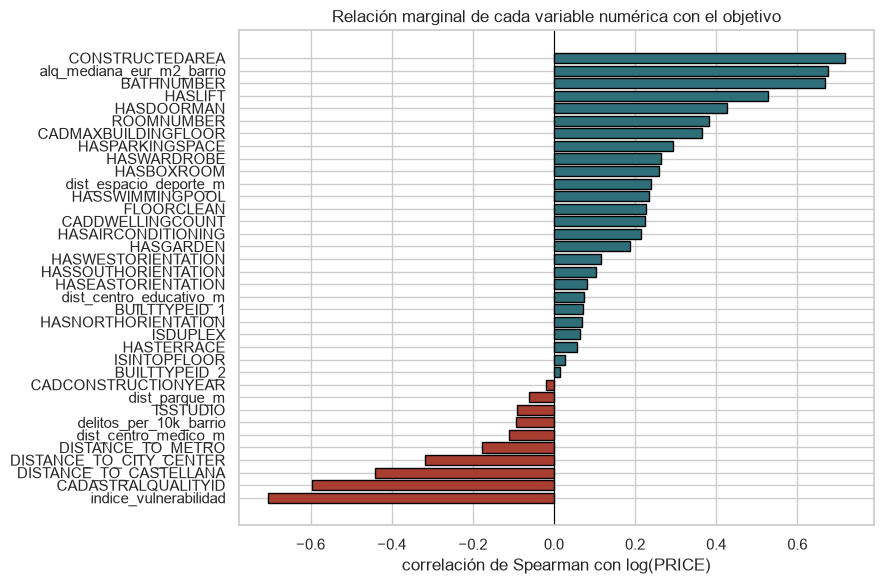

In [37]:
corr_price = correlaciones_numericas(df_limpio, "log_PRICE")
corr_price = corr_price.drop(index=[TARGET], errors="ignore")

fig, ax = plt.subplots(figsize=(9, 6))
orden = corr_price.sort_values("corr_spearman")
colores = ["#a83e32" if v < 0 else "#2f6f7a" for v in orden["corr_spearman"]]
ax.barh(orden.index, orden["corr_spearman"], color=colores, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("correlación de Spearman con log(PRICE)")
ax.set_title("Relación marginal de cada variable numérica con el objetivo")
plt.tight_layout(); plt.show()

**Aviso que condiciona los notebooks 02 y 03:** esta correlación mide relación
**monótona y marginal**. Una variable con correlación ~0 puede tener una relación fuerte
pero **en U** (se cancela), y una con correlación alta puede ser un simple *proxy* de
otra. Los dos casos aparecen en este dataset, y son la razón de que el notebook 03 no
decida con esta tabla.

### 6.1 Correlación entre explicativas

El VIF de la celda siguiente resume, para cada variable, cuánto la predicen *todas las
demás juntas* — pero no dice **con cuál** está correlacionada. Para eso hace falta la
matriz completa entre explicativas (sin el objetivo, que ya se cubrió arriba).

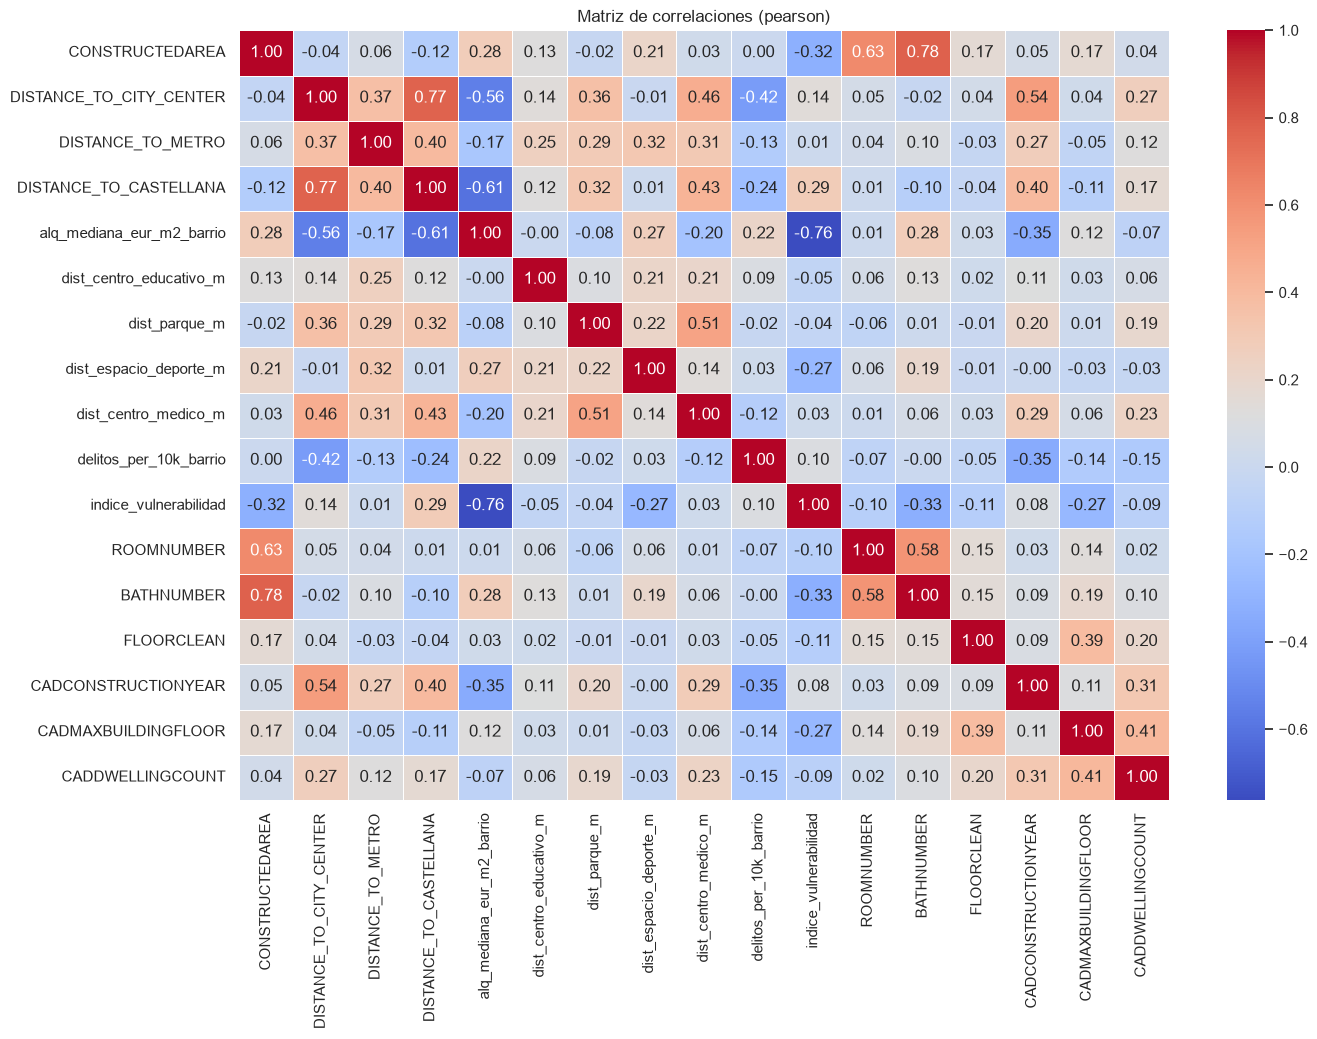

In [38]:
plot_corr_matrix(df_limpio, NUM_EXPLICATIVAS)

In [39]:
# Pares con |r| >= 0.3 ("moderada" en adelante); umbral 0.3 ~ "moderada" en adelante
corr_matrix = df_limpio[NUM_EXPLICATIVAS].apply(pd.to_numeric, errors="coerce").corr(method="pearson")

pares_corr = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1))
    .stack()
    .dropna()
    .rename("corr")
    .reset_index()
    .rename(columns={"level_0": "var_1", "level_1": "var_2"})
)
pares_corr["abs_corr"] = pares_corr["corr"].abs()
pares_corr = pares_corr.sort_values("abs_corr", ascending=False).reset_index(drop=True)

pares_corr_moderados = pares_corr[pares_corr["abs_corr"] >= 0.3].reset_index(drop=True)
print(f"{len(pares_corr_moderados)} de {len(pares_corr)} pares con |r| >= 0.3")
pares_corr_moderados

26 de 136 pares con |r| >= 0.3


,var_1,var_2,corr,abs_corr
0,CONSTRUCTEDAREA,BATHNUMBER,0.775533,0.775533
1,DISTANCE_TO_CITY_CENTER,DISTANCE_TO_CASTELLANA,0.767702,0.767702
2,alq_mediana_eur_m2_barrio,indice_vulnerabilidad,-0.762505,0.762505
3,CONSTRUCTEDAREA,ROOMNUMBER,0.626955,0.626955
4,DISTANCE_TO_CASTELLANA,alq_mediana_eur_m2_barrio,-0.610089,0.610089
5,ROOMNUMBER,BATHNUMBER,0.584622,0.584622
6,DISTANCE_TO_CITY_CENTER,alq_mediana_eur_m2_barrio,-0.555837,0.555837
7,DISTANCE_TO_CITY_CENTER,CADCONSTRUCTIONYEAR,0.540164,0.540164
8,dist_parque_m,dist_centro_medico_m,0.511427,0.511427
9,DISTANCE_TO_CITY_CENTER,dist_centro_medico_m,0.463065,0.463065


29 de los 136 pares posibles entre explicativas tienen |r| >= 0,3. Más allá de las dos
parejas ya señaladas por el VIF de la celda siguiente
(`alq_mediana_eur_m2_barrio`/`indice_vulnerabilidad` y las dos distancias al centro),
destacan:

- `CONSTRUCTEDAREA`, `BATHNUMBER` y `ROOMNUMBER` forman un trío correlacionado
  (r entre 0,58 y 0,78) — esperable, son *proxies* del tamaño de la vivienda.
- `dist_parque_m` y `dist_centro_medico_m` (r≈0,66): dos distancias a POI que
  probablemente capturan el mismo gradiente centro-periferia.
- `CADMAXBUILDINGFLOOR` y `CADDWELLINGCOUNT` (r≈0,41), y `CADMAXBUILDINGFLOOR` y
  `FLOORCLEAN` (r≈0,39) — esta última apoya, con un dato adicional, la decisión de usar
  `CADMAXBUILDINGFLOOR` como variable condicionante al imputar `FLOORCLEAN` (§3.3).

Pese al número de pares con correlación moderada, ninguno se traduce en un VIF alto de
forma aislada (celda siguiente): la colinealidad, donde existe, está repartida entre
varias variables en vez de concentrada en una sola pareja dominante.

Además, las correlaciones encontradas podían ser esperadas, y no significan necesariamente que las variables no aporten valor separadamente.

In [40]:
vif = vif_table(df_limpio, NUM_EXPLICATIVAS)
vif.head(10)

,variable,VIF
0,alq_mediana_eur_m2_barrio,5.773793
1,DISTANCE_TO_CITY_CENTER,3.850683
2,indice_vulnerabilidad,3.845897
3,DISTANCE_TO_CASTELLANA,3.147549
4,CONSTRUCTEDAREA,2.994079
5,BATHNUMBER,2.798043
6,ROOMNUMBER,1.901604
7,dist_centro_medico_m,1.634655
8,CADCONSTRUCTIONYEAR,1.599445
9,dist_parque_m,1.527091


Ningún VIF supera 10, pero las dos parejas que ya destacaban en la matriz de
correlación (§6.1) son las de VIF más alto: `alq_mediana_eur_m2_barrio` (6,28) e
`indice_vulnerabilidad` (4,12), y las dos distancias al centro. Reaparecerán en el
notebook 03.

> El VIF se recalcula en el notebook 04 **después** de transformar: el binning cambia
> por completo la estructura de colinealidad y estas conclusiones no se trasladan
> automáticamente.

## 7. Variables cualitativas frente al objetivo

Para los flags binarios y la ordinal se usa la V de Cramer, que no asume monotonía.

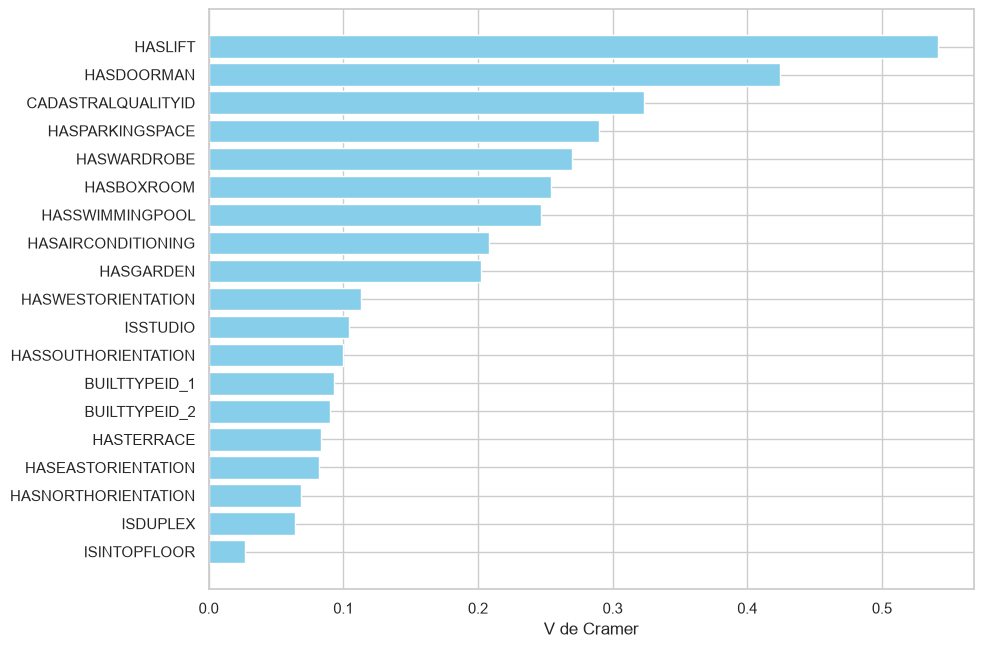

In [41]:
CAT_COLS = [c for c in FLAGS_BINARIOS + ORDINAL if c in df_limpio.columns]
cramer_target = graficoVcramer(df_limpio[CAT_COLS], df_limpio["log_PRICE"])

In [42]:
redundancia = detectar_redundancia_categorica(df_limpio, CAT_COLS, threshold=0.3)
print("Pares de cualitativas redundantes (V de Cramer >= 0,3):")
print(redundancia.to_string(index=False) if len(redundancia) else "  ninguno")

Pares de cualitativas redundantes (V de Cramer >= 0,3):
             var_1              var_2  cramers_v
   HASSWIMMINGPOOL          HASGARDEN      0.666
   HASPARKINGSPACE    HASSWIMMINGPOOL      0.543
   HASPARKINGSPACE          HASGARDEN      0.477
   HASPARKINGSPACE         HASBOXROOM      0.445
        HASBOXROOM    HASSWIMMINGPOOL      0.417
           HASLIFT CADASTRALQUALITYID      0.408
        HASBOXROOM          HASGARDEN      0.358
           HASLIFT         HASDOORMAN      0.354
HASAIRCONDITIONING        HASWARDROBE      0.349
        HASDOORMAN CADASTRALQUALITYID      0.330


Similarmente, vemos que en general las instalaciones de los inmuebles tienen correlación (p. ej, piscina y jardín).

## 8. Síntesis: primer filtro

Cada variable se etiqueta según la **fuerza de su señal** combinando Spearman y V de
Cramer frente al objetivo (§6-7) con VIF/correlación entre explicativas (§6.1) y los
hallazgos de §3-5. No es un umbral mecánico sobre un único número:
`CADCONSTRUCTIONYEAR` se salva por V de Cramer pese a spearman ≈ 0.

- **fuerte** — señal clara en al menos una métrica, sin caveat que la complique.
- **ambigua** — hay señal real, pero algo (no linealidad, colinealidad, origen
  declarativo) exige mirarla más de cerca en el 02 o el 03.
- **débil** — señal marginal en ambas métricas.

Es una descripción de la señal, no una decisión sobre la variable: ninguna columna se
elimina aquí. Qué entra al modelo lo decide el notebook 03.

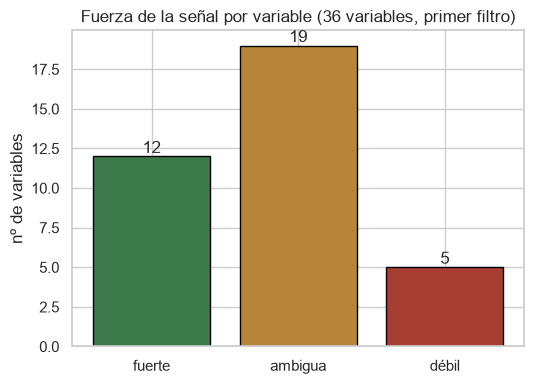

In [ ]:
# (variable, señal, razon) — juicio razonado, no una fórmula sobre un único número.
# tipo se deriva de la taxonomía de §1, no se repite a mano.
RAZONES = {
    # --- continuas: tamaño y localización ---
    "CONSTRUCTEDAREA": ("fuerte", "Señal dominante (spearman 0,72)."),
    "alq_mediana_eur_m2_barrio": ("ambigua",
        "Corr. fuerte pero VIF más alto del dataset: colineal con indice_vulnerabilidad."),
    "indice_vulnerabilidad": ("ambigua",
        "Misma colinealidad que alq_mediana_eur_m2_barrio, en espejo."),
    "DISTANCE_TO_CITY_CENTER": ("ambigua",
        "Colineal con DISTANCE_TO_CASTELLANA (r=0,78)."),
    "DISTANCE_TO_CASTELLANA": ("ambigua",
        "Colineal con DISTANCE_TO_CITY_CENTER."),
    "DISTANCE_TO_METRO": ("ambigua",
        "Señal débil-moderada; probable proxy del nivel de precio del barrio."),
    "dist_centro_educativo_m": ("débil",
        "Señal marginal; por debajo de la resolución espacial del dato (§0)."),
    "dist_parque_m": ("débil",
        "Señal marginal; colineal con dist_centro_medico_m."),
    "dist_espacio_deporte_m": ("ambigua",
        "Signo llamativo: posible confusión con el gradiente centro-periferia."),
    "dist_centro_medico_m": ("débil",
        "Señal débil; mismo gradiente espacial que otras distancias."),
    "delitos_per_10k_barrio": ("ambigua",
        "V de Cramer mucho mayor que spearman: relación no monótona (posible U)."),
    # --- discretas / edificio ---
    "ROOMNUMBER": ("fuerte", "Señal moderada-fuerte; parte del trío de tamaño."),
    "BATHNUMBER": ("fuerte", "Segunda variable numérica más correlacionada con el objetivo."),
    "FLOORCLEAN": ("fuerte", "VIF más bajo del dataset; imputación condicional (§3.3)."),
    "CADCONSTRUCTIONYEAR": ("ambigua",
        "Spearman casi nulo pero V de Cramer notable: forma no lineal."),
    "CADMAXBUILDINGFLOOR": ("fuerte",
        "Señal moderada; 0 significa 'sin dato', no altura real (§3.3)."),
    "CADDWELLINGCOUNT": ("fuerte", "Señal débil-moderada, VIF bajo."),
    "CADASTRALQUALITYID": ("fuerte",
        "Corr. de rango fuerte; no estrictamente monótona en los extremos."),
    # --- flags estructurales (no declarativos) ---
    "HASLIFT": ("fuerte", "Mayor V de Cramer de los flags; estructural, difícil de declarar mal."),
    "HASDOORMAN": ("fuerte", "Segunda mayor señal entre los flags."),
    "HASPARKINGSPACE": ("fuerte",
        "Absorbe la prima de las viviendas con parking incluido en el precio (§4)."),
    "BUILTTYPEID_1": ("fuerte", "Tipología constructiva, categoría cerrada."),
    "BUILTTYPEID_2": ("fuerte", "Corr. lineal casi nula pero V de Cramer notable."),
    # --- instalaciones declarativas: señal real pero de fiabilidad cuestionable ---
    "HASWARDROBE": ("ambigua", "Señal moderada pero declarativa: riesgo de drift."),
    "HASBOXROOM": ("ambigua", "Misma reserva declarativa que HASWARDROBE."),
    "HASSWIMMINGPOOL": ("ambigua", "Redundante con HASGARDEN y HASPARKINGSPACE (§7)."),
    "HASAIRCONDITIONING": ("ambigua", "Colineal con HASWARDROBE; declarativa."),
    "HASGARDEN": ("ambigua", "Redundante con HASSWIMMINGPOOL y HASBOXROOM (§7)."),
    "HASTERRACE": ("ambigua", "Señal débil; declarativa."),
    "ISSTUDIO": ("ambigua", "Ligada a ROOMNUMBER==0; posible relación no lineal."),
    # --- orientaciones: débiles y, además, categoría abierta ---
    "HASNORTHORIENTATION": ("ambigua",
        "Señal marginal; orientación no es categoría cerrada (revisado en 03 §4.3)."),
    "HASSOUTHORIENTATION": ("ambigua", "Ídem HASNORTHORIENTATION."),
    "HASEASTORIENTATION": ("ambigua", "Ídem HASNORTHORIENTATION."),
    "HASWESTORIENTATION": ("ambigua", "Ídem, la más fuerte de las cuatro."),
    # --- señal débil en las dos métricas, sin brecha ---
    "ISDUPLEX": ("débil", "Señal débil en ambas métricas, sin brecha entre ellas."),
    "ISINTOPFLOOR": ("débil", "Señal prácticamente nula en ambas métricas."),
}

TIPOS = {}
for c in CONTINUAS:
    TIPOS[c] = "continua"
for c in DISCRETAS_L:
    TIPOS[c] = "discreta"
for c in ORDINAL:
    TIPOS[c] = "ordinal"
for c in FLAGS_BINARIOS:
    if c in df_limpio.columns:
        TIPOS[c] = "flag_binario"

todas_candidatas = NUM_EXPLICATIVAS + CAT_COLS
faltantes = set(todas_candidatas) - set(RAZONES)
assert not faltantes, f"Sin señal razonada: {faltantes}"

filas = []
for col in todas_candidatas:
    señal, razon = RAZONES[col]
    filas.append({
        "variable": col,
        "tipo": TIPOS[col],
        "spearman_abs": round(corr_price["corr_spearman"].abs().get(col, np.nan), 3),
        "cramer_v": round(cramer_target.get(col, np.nan), 3),
        "señal": señal,
        "razon": razon,
    })

tabla_idoneidad = pd.DataFrame(filas).set_index("variable")
conteo = tabla_idoneidad["señal"].value_counts().reindex(["fuerte", "ambigua", "débil"])

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(conteo.index, conteo.values, color=["#3d7a4a", "#b8863a", "#a83e32"], edgecolor="black")
for i, v in enumerate(conteo.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
ax.set_ylabel("nº de variables")
ax.set_title(f"Fuerza de la señal por variable ({len(tabla_idoneidad)} variables, primer filtro)")
plt.tight_layout(); plt.show()

In [44]:
pd.set_option("display.max_colwidth", 100)
print(tabla_idoneidad[["tipo", "spearman_abs", "cramer_v", "señal", "razon"]]
      .sort_values("señal")
      .to_string())

                                   tipo  spearman_abs  cramer_v    señal                                                                            razon
variable                                                                                                                                                 
DISTANCE_TO_CITY_CENTER        continua         0.318       NaN  ambigua                                    Colineal con DISTANCE_TO_CASTELLANA (r=0,78).
DISTANCE_TO_METRO              continua         0.178       NaN  ambigua             Señal débil-moderada; probable proxy del nivel de precio del barrio.
DISTANCE_TO_CASTELLANA         continua         0.440       NaN  ambigua                                            Colineal con DISTANCE_TO_CITY_CENTER.
alq_mediana_eur_m2_barrio      continua         0.675       NaN  ambigua  Corr. fuerte pero VIF más alto del dataset: colineal con indice_vulnerabilidad.
dist_espacio_deporte_m         continua         0.239       NaN  ambigua    